# EPC02 Forca bruta: Ordenação

Implemente os seguintes algoritmos de ordenação baseados na estratégia Força Bruta:

1. BubbleSort
2. BublleSort com critério de parada melhorado
3. SelectionSort
4. SelectionSort melhorado

Todos os algoritmos devem ser implementados em python sem utilizar nenhuma biblioteca externa. Eles devem receber como parâmetro uma lista de elementos e ordenar esta lista.
 
Você deve implementar também um código que gere um gráfico comparando o desempenho dos algoritmos utilizando listas com diferentes tamanhos.

Você deve enviar o código dos algoritmos e do gráfico em um arquivo único no formato .ipypnb. Ao enviar o seu EPC, por favor, nomeie o seu arquivo para: EPC02-SeuNome.ipynb

In [ ]:
from typing import List

In [ ]:
def swap(list: List, pos1, pos2):
    list[pos1], list[pos2] = list[pos2], list[pos1]
    return list

In [ ]:
#complexidade theta(n²)
def bubble_sort(L:List):
    for i in range(len(L)-1):
        for j in range(len(L)-1-i):
            if L[j] > L[j+1]:
                swap(L, j, j+1)


In [ ]:
#complexidade theta(n²)
def bubble_sort_with_altered_stop(L:List)->List:
    
    for i in range(len(L)-1):
        did_make_swap=False
        for j in range(len(L)-1-i):
            if L[j] > L[j+1]:
                swap(L, j, j+1)
                did_make_swap=True
        if not did_make_swap:
            break

In [ ]:
#complexidade theta(n²)
def selection_sort(L:List)->List:
    for i in range(len(L)-1):
        for j in range(i+1, len(L)):
            if L[j] < L[i]:
                swap(L, i, j)

In [ ]:
#complexidade theta(n²)
def selection_sort_better(L:List)->List:
    for i in range(len(L) - 1):
        min = i

        for j in range(i+1, len(L)):
            if L[j] < L[min]:
                min = j
        swap(L, i, min)

In [ ]:
# Coleta de dados para o experimento
import time
from numpy import random
DOMAIN = 1000000000 #1B

random.seed(17)

def avgTime(L,func,rounds):
  
  s = 0
  for i in range(rounds):
    start = time.time()
    func(L)
    end = time.time()
    s += end-start
  return s/rounds

#defines the algorithms to be processed
algorithms = [bubble_sort, bubble_sort_with_altered_stop, selection_sort, selection_sort_better]

#defines the number of times each algorithm will be processed to find the average time
num_rounds = 3

##sizes 1M, 5M, 10M, 15M, 20M
sizes = [10000, 50000, 100000, 500000, 1000000] 
mapSizeToTime = dict()
for i in range(3):
  print(f"Starting round {i+1}")

  #create a list with random numbers
  L=list(random.randint(DOMAIN, size=sizes[i]))

  ##Map list size to algorithm average time
  for algorithm in algorithms:
    mapSizeToTime[f"{algorithm.__name__ }##{sizes[i]}"] = avgTime(L, algorithm, num_rounds)

print(f"Finish data collection")

Starting round 3
Finish data collection


In [38]:
#formata os dados do experimento para exibir
import pandas as pd
df = pd.DataFrame.from_dict(mapSizeToTime, orient='index',columns=['Time'])
df['Algorithm'] = [i.split("##")[0] for i in df.index]
df['Size'] = [int(i.split("##")[1]) for i in df.index]
df

,Time,Algorithm,Size
bubble_sort##1000,0.030151,bubble_sort,1000
bubble_sort_with_altered_stop##1000,0.000060,bubble_sort_with_altered_stop,1000
selection_sort##1000,0.014569,selection_sort,1000
selection_sort_better##1000,0.014004,selection_sort_better,1000
bubble_sort##5000,0.639914,bubble_sort,5000
bubble_sort_with_altered_stop##5000,0.000544,bubble_sort_with_altered_stop,5000
selection_sort##5000,0.397345,selection_sort,5000
selection_sort_better##5000,0.339236,selection_sort_better,5000
bubble_sort##10000,2.165395,bubble_sort,10000
bubble_sort_with_altered_stop##10000,0.000379,bubble_sort_with_altered_stop,10000


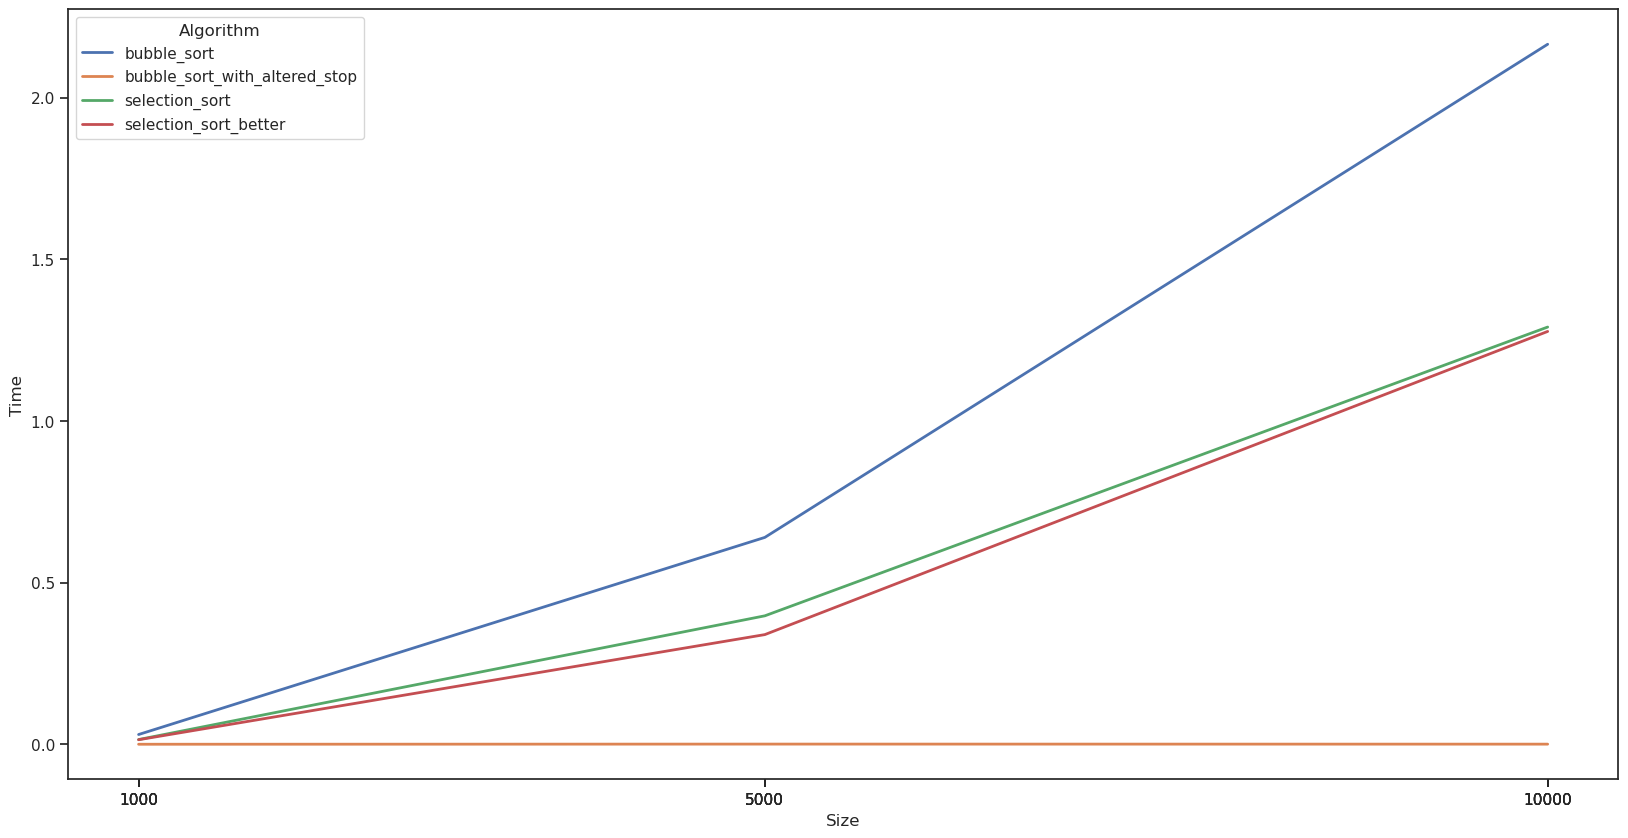

<Figure size 2000x1000 with 0 Axes>

In [39]:
#resultado do experimento
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

##Defines font size and line width
sns.set(font_scale=1, style="ticks", rc={"lines.linewidth": 2})

##Defines plot size
plt.rcParams['figure.figsize'] = [20, 10]

g = sns.lineplot(x='Size', y='Time', hue='Algorithm', data=df)
#g.set_yscale('log')
fig = plt.figure()
g.set(xticks=[i for i in df.Size])
plt.show()